-----
# Importações.
Tratamento inicial de data para (DataTime).
--

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
#---- LEITURA DO ARQUIVO CSV ----
df = pd.read_csv("Base_Varejo.csv", sep=";", encoding="cp1252", decimal=",")
# Converte a coluna de data de admissão para o tipo datetime
df["DATA"] = pd.to_datetime(
    df["DATA"],
    format="%d/%m/%Y",
    errors="coerce"
)

#---- EXIBIÇÃO DAS 5 PRIMEIRAS LINHAS e 5 ultimas LINHAS DO DATAFRAME ----
df.head(5)
#df.tail(5)

# Indentificação das colunas do dataframe: para poder ter noção do que agrupar, filtrar e analisar os dados.
# DATA, Compra_iD, Cliente_ID, CL_Genero, CL_EstadoCivil, CL_Filhos, Cl_Segmento, PR_IDdoProduto, PR_CategoriadoProduto, PR_NomedoProduto


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


----
# Limpeza de colunas nulas (Unnamed)

In [21]:
# Remove todas as colunas cujo nome começa com 'Unnamed'
df = df.loc[:, ~df.columns.str.contains('^Unnamed')] 
print(df.columns)


Index(['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG',
       'PR_ID', 'PR_CAT', 'PR_NOME', 'ANO', 'MES', 'DIA', 'SEMANA', 'MES_ANO'],
      dtype='str')


----
# Criação das colunas de "DATA"

In [3]:
# Criar colunas derivadas para analise de groupby (datas)
df["ANO"] = df["DATA"].dt.year # o dt.year extrai o ano da coluna de data e cria uma nova coluna chamada "ANO" no dataframe. importante colocar o dt
df["MES"] = df["DATA"].dt.month # cria a coluna do mes
df["DIA"] = df["DATA"].dt.day # cria a coluna do dia
df["SEMANA"] = df["DATA"].dt.isocalendar().week # o dt.isocalendar().week extrai o número da semana do ano da coluna de data e cria uma nova coluna chamada "SEMANA" no dataframe.
df["MES_ANO"] = df["DATA"].dt.to_period("M") # o dt.to_period("M") converte a coluna de data para um período mensal e cria uma nova coluna chamada "MES_ANO" no dataframe.
print(df.head(5))

        DATA  CO_ID  CL_ID CL_GENERO  CL_EC  CL_FHL CL_SEG  PR_ID     PR_CAT  \
0 2019-02-01   1000    534         M      4       1      C     67    BEBIDAS   
1 2019-02-01   1000    534         M      4       1      C     70    BEBIDAS   
2 2019-02-01   1000    534         M      4       1      C    178    HIGIENE   
3 2019-02-01   1000    534         M      4       1      C      4  ALIMENTOS   
4 2019-02-01   1000    534         M      4       1      C    175    LIMPEZA   

                PR_NOME   ANO  MES  DIA  SEMANA  MES_ANO  
0  REFRIGERANTE GUARANA  2019    2    1       5  2019-02  
1   REFRIGERANTE OUTROS  2019    2    1       5  2019-02  
2       LENCO UMEDECIDO  2019    2    1       5  2019-02  
3               ABACAXI  2019    2    1       5  2019-02  
4     LIMPADOR MULTIUSO  2019    2    1       5  2019-02  


----
# Analise da Base de Dados

In [4]:
print(f"DataFrame possui {df.shape[0]} linhas e {df.shape[1]} colunas.")
print('\n' + '='*50)
print(f"Nomes das Colunas: ")
print(df.columns)
print('\n' + '='*50)
print(f"Tipos de Dados: ")
print(df.dtypes)

DataFrame possui 830000 linhas e 15 colunas.

Nomes das Colunas: 
Index(['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG',
       'PR_ID', 'PR_CAT', 'PR_NOME', 'ANO', 'MES', 'DIA', 'SEMANA', 'MES_ANO'],
      dtype='str')

Tipos de Dados: 
DATA         datetime64[us]
CO_ID                 int64
CL_ID                 int64
CL_GENERO               str
CL_EC                 int64
CL_FHL                int64
CL_SEG                  str
PR_ID                 int64
PR_CAT                  str
PR_NOME                 str
ANO                   int32
MES                   int32
DIA                   int32
SEMANA               UInt32
MES_ANO           period[M]
dtype: object


In [5]:
print(df.info()) # para verificar o número de valores não nulos em cada coluna, e confirmar que estão no formato esperado (ex: sem espaços, sem caracteres estranhos, etc).

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   DATA       830000 non-null  datetime64[us]
 1   CO_ID      830000 non-null  int64         
 2   CL_ID      830000 non-null  int64         
 3   CL_GENERO  830000 non-null  str           
 4   CL_EC      830000 non-null  int64         
 5   CL_FHL     830000 non-null  int64         
 6   CL_SEG     830000 non-null  str           
 7   PR_ID      830000 non-null  int64         
 8   PR_CAT     830000 non-null  str           
 9   PR_NOME    830000 non-null  str           
 10  ANO        830000 non-null  int32         
 11  MES        830000 non-null  int32         
 12  DIA        830000 non-null  int32         
 13  SEMANA     830000 non-null  UInt32        
 14  MES_ANO    830000 non-null  period[M]     
dtypes: UInt32(1), datetime64[us](1), int32(3), int64(5), period[M](1), str(4)
memor

In [6]:
print(df.describe()) # para obter uma visão geral das colunas numéricas, incluindo contagem, média, desvio padrão, valores mínimos e máximos, e os quartis.
# nao aparece haver colunas numéricas, então o resultado do describe() é vazio.

                             DATA         CO_ID          CL_ID          CL_EC  \
count                      830000  830000.00000  830000.000000  830000.000000   
mean   2020-12-06 14:55:46.421204  460045.08989     499.595204       2.596911   
min           2019-01-04 00:00:00    1000.00000       1.000000       1.000000   
25%           2020-01-09 00:00:00  233117.00000     254.000000       2.000000   
50%           2020-12-27 00:00:00  456517.00000     498.000000       3.000000   
75%           2021-10-20 00:00:00  690132.00000     746.000000       4.000000   
max           2022-12-08 00:00:00  919822.00000    1000.000000       5.000000   
std                           NaN  265465.24754     287.568253       1.170599   

             CL_FHL          PR_ID            ANO            MES  \
count  830000.00000  830000.000000  830000.000000  830000.000000   
mean        1.14654     115.051855    2020.458914       6.234892   
min         0.00000       1.000000    2019.000000       1.000000  

In [7]:
#para verificar os valores únicos de cada coluna, e confirmar que estão no formato esperado (ex: sem espaços, sem caracteres estranhos, etc).
df[["DATA","CO_ID","CL_ID","CL_GENERO","CL_EC","CL_FHL","CL_SEG","PR_ID","PR_CAT","PR_NOME"]].head(10) 


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO
5,2019-02-01,1000,534,M,4,1,C,187,HIGIENE,HASTES FLEXIVEIS
6,2019-02-01,1000,534,M,4,1,C,163,ALIMENTOS,MORTADELA
7,2019-02-01,1000,534,M,4,1,C,11,ALIMENTOS,AZEITE
8,2019-02-01,1000,534,M,4,1,C,95,LIMPEZA,AMACIANTE
9,2019-02-01,1000,534,M,4,1,C,198,BEBIDAS,ENERGETICO


----
# Tratamento da Categoria "#N/D" na coluna "PR_CAT"

In [8]:
print('Valores únicos por coluna:')
print(df.nunique())
df["PR_CAT"].value_counts() # para verificar os valores únicos da coluna "PR_CAT", e confirmar que estão no formato esperado (ex: sem espaços, sem caracteres estranhos, etc).
# aparição de 1 categoria ND tratar com if-else

if "#N/D" in df["PR_CAT"].values: # se nao colocar o .values ele não reconhece o #N/D, tem que colocar o .values para reconhecer o valor dentro da coluna
    print("#N/D encontrado, tem que tratar!")
    df["PR_CAT"] = df["PR_CAT"].replace("#N/D", "PRODUTO_SEM_CATEGORIA") # .replace serve para tocar a "Legenda de N/D para sem categoria"
    print("tratamento realizado!")
else:
    print("Nenhum valor #N/D encontrado, não é necessário tratamento.")
df["PR_CAT"].value_counts()
# Remove a coluna chamada "sem categoria"



Valores únicos por coluna:
DATA           333
CO_ID        18471
CL_ID         1000
CL_GENERO        2
CL_EC            5
CL_FHL           5
CL_SEG           3
PR_ID          229
PR_CAT           7
PR_NOME        118
ANO              4
MES             12
DIA             31
SEMANA          53
MES_ANO         48
dtype: int64
#N/D encontrado, tem que tratar!
tratamento realizado!


PR_CAT
ALIMENTOS                434767
HIGIENE                  155574
LIMPEZA                  145754
BEBIDAS                   43299
PET                       32399
ACESSORIOS                14557
PRODUTO_SEM_CATEGORIA      3650
Name: count, dtype: int64

In [9]:
# isso serve para juntar PRODUTO_SEM_CATEGORIA com sem categoria 

df["PR_CAT"] = df["PR_CAT"].replace(
    {"sem categoria": "PRODUTO_SEM_CATEGORIA"}
)
print(df["PR_CAT"].value_counts()) # para verificar se a coluna "PR_CAT" foi atualizada corretamente, e confirmar que o tratamento foi eficaz.
# o grafico sera retirado manualmente a categoria "PRODUTO_SEM_CATEGORIA" para não atrapalhar a análise de distribuição das categorias de produtos.

PR_CAT
ALIMENTOS                434767
HIGIENE                  155574
LIMPEZA                  145754
BEBIDAS                   43299
PET                       32399
ACESSORIOS                14557
PRODUTO_SEM_CATEGORIA      3650
Name: count, dtype: int64


In [10]:
# Seleciona apenas as linhas onde PR_CAT é "#N/D" assim da pra saber se sobrou algum valor #N/D depois do tratamento, e confirmar que o tratamento foi eficaz.
linhas_nd = df.loc[df["PR_CAT"] == "#N/D"]

print(linhas_nd)
print(df["PR_CAT"].isnull().sum()) # para verificar se há valores nulos na coluna "PR_CAT" após o tratamento, e confirmar que o tratamento foi eficaz.

Empty DataFrame
Columns: [DATA, CO_ID, CL_ID, CL_GENERO, CL_EC, CL_FHL, CL_SEG, PR_ID, PR_CAT, PR_NOME, ANO, MES, DIA, SEMANA, MES_ANO]
Index: []
0


----
# Estatística Descritiva em cima da coluna CL_FHL (Filhos)
----
Contagem de clientes: 1000

Total de filhos dos clientes: 1136

Mediana de filhos por cliente: 0.00

Média de filhos por cliente: 1.14

Máximo de filhos por cliente: 4.00

Mínimo de filhos por cliente: 0.00

Desvio padrão de filhos por cliente: 1.41


In [11]:

# Esta puxando os valores únicos da coluna CL_ID e retirando as duplicatas porque se fizer so com .sum vai contar os filhos de cada compra, e não o total de filhos dos clientes, que é o que queremos.
df_unicos = df.drop_duplicates(subset="CL_ID")

# isso e a mesma coisa que o describle, mais de uma forma melhor de leitura.
print(f"Contagem de clientes: {df_unicos['CL_FHL'].count()}") 
print(f"Total de filhos dos clientes: {df_unicos['CL_FHL'].sum()}")
print(f"Mediana de filhos por cliente: {df_unicos['CL_FHL'].median():.2f}")
print(f"Média de filhos por cliente: {df_unicos['CL_FHL'].mean():.2f}")
print(f"Máximo de filhos por cliente: {df_unicos['CL_FHL'].max():.2f}")
print(f"Mínimo de filhos por cliente: {df_unicos['CL_FHL'].min():.2f}")
print(f"Desvio padrão de filhos por cliente: {df_unicos['CL_FHL'].std():.2f}")  

Contagem de clientes: 1000
Total de filhos dos clientes: 1136
Mediana de filhos por cliente: 0.00
Média de filhos por cliente: 1.14
Máximo de filhos por cliente: 4.00
Mínimo de filhos por cliente: 0.00
Desvio padrão de filhos por cliente: 1.41


In [12]:
#Estatisticas descritivas básicas para coluna de número de filhos do cliente (média; mediana; desvio padrão; moda; máximo; mínimo; e contagem).
df["CL_FHL"].describe()

count    830000.00000
mean          1.14654
std           1.41696
min           0.00000
25%           0.00000
50%           0.00000
75%           2.00000
max           4.00000
Name: CL_FHL, dtype: float64

----
# Agrupamento com Visualizações
 --- 
# Gráfico 1
# Número de Compras por Ano

as explicações ficam abaixo dos gráficos!

ANO
2019    199036
2020    218367
2021    245259
2022    167338
Name: CO_ID, dtype: int64


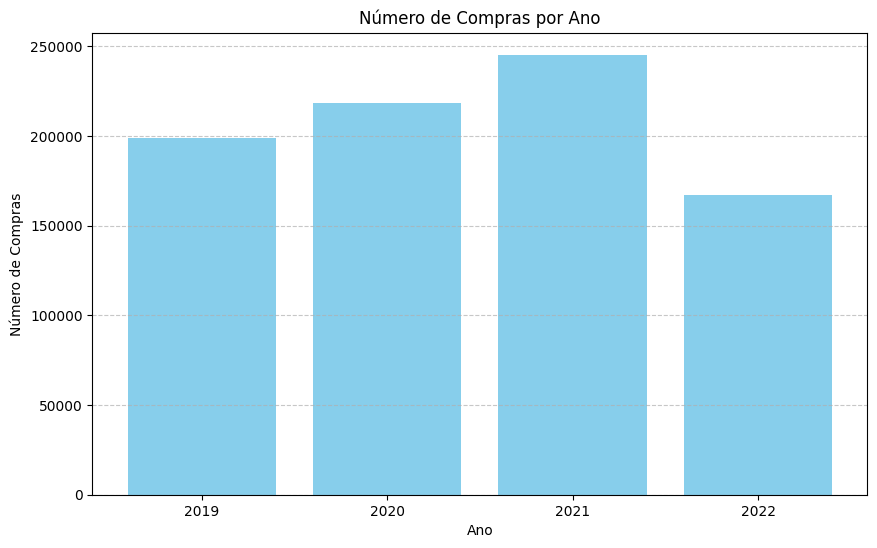

In [13]:
# agrupamento 1 (DATA(ANO) COM COMPRA_ID) grafico de histograma
agrupamento1 = df.groupby("ANO")["CO_ID"].count()   # para agrupar os dados por ano e contar o número de categorias de produtos distintas em cada ano. 
print(agrupamento1)

plt.figure(figsize=(10, 6))
plt.bar(agrupamento1.index, agrupamento1.values, width=0.8, color='skyblue')
plt.title("Número de Compras por Ano")
plt.xlabel("Ano")
plt.ylabel("Número de Compras")
plt.xticks(agrupamento1.index)  # para garantir que os rótulos do eixo x sejam os anos
plt.grid(axis='y', linestyle='--', alpha=0.7)   
plt.show()

# O que esse Gráfico mostra:
Cada barra representa um ano e a altura deles significa o número de compras ao longo do ano.

# Porque ele e útil ?
    • Saber o número de compras ao longo dos anos é bom para acompanhar a evolução do comportamento do consumidor e a performace da empresa ao longo do tempo.

# Gráfico 2
# Número de compras por Gênero

CL_GENERO
F    432576
M    397424
Name: CO_ID, dtype: int64


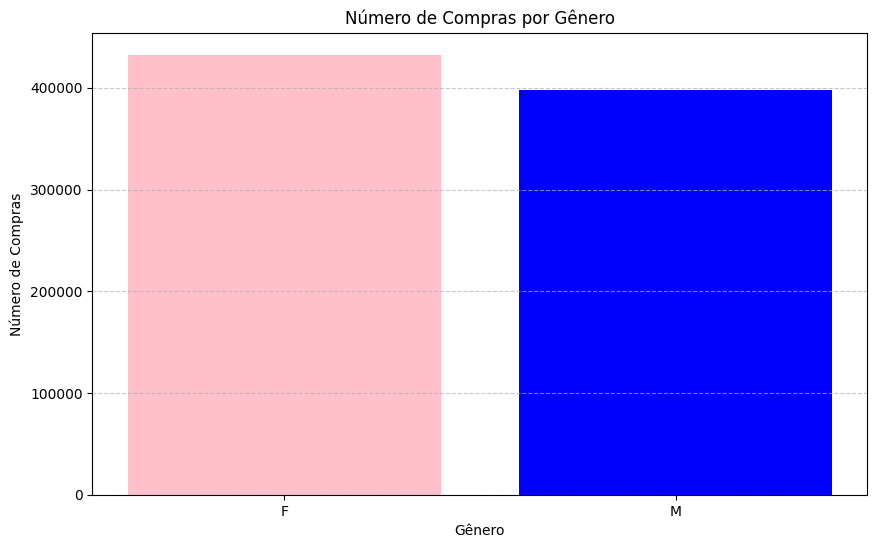

In [14]:
# Agrupamento 2 (CL_GENERO COM MAIS VENDAS C0_ID) grafico de barras para a comparação entre categorias
agrupamento2 = df.groupby("CL_GENERO")["CO_ID"].count()   # para agrupar os dados por gênero do cliente e contar o número de compras distintas em cada gênero.
print(agrupamento2)

plt.figure(figsize=(10, 6))
plt.bar(agrupamento2.index, agrupamento2.values, color=['pink', 'blue'])
plt.title("Número de Compras por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Número de Compras")
plt.xticks(agrupamento2.index)  # para garantir que os rótulos do eixo x sejam os gêneros
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# O que o gráfico mostra ?
A distribuição de vendas por gênero.

# Porque ele é útil ?
    • saber a distribuição de número de Compras por Gênero é importante porque ajuda as empresa a entender padrões de consumo e tomar decisões mais estratégicas 

# Gráfico 3 (sem agrupamento)


# Visualização da Distribuição de Categoria 

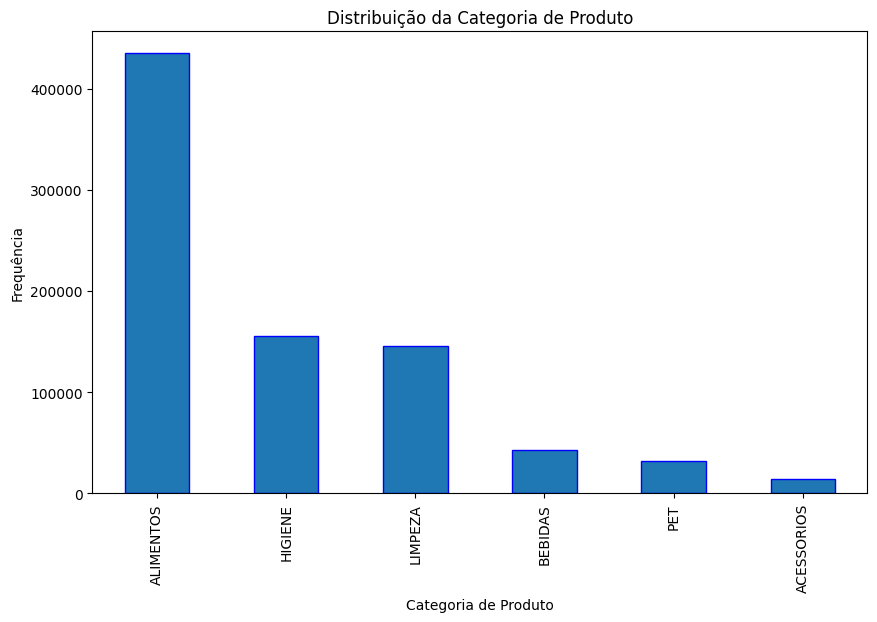

In [15]:

# Remover a categoria "PRODUTO_SEM_CATEGORIA" para não atrapalhar a análise de distribuição das categorias de produtos
df_filtrado = df[df["PR_CAT"] != "PRODUTO_SEM_CATEGORIA"] # se não colocar # e a barra ela não limpa

# Contagem das categorias sem "PRODUTO_SEM_CATEGORIA"
contagem = df_filtrado["PR_CAT"].value_counts()

# Gráfico de barras
contagem.plot(kind="bar", figsize=(10,6), edgecolor="blue")
plt.title("Distribuição da Categoria de Produto")
plt.xlabel("Categoria de Produto")
plt.ylabel("Frequência")
plt.show()



# O que o gráfico mostra ?
A distribuição de vendas por categoria de produtos.

# Porque ele é útil ?
    • Identificação rápida de proporções: você consegue ver quais categorias são mais relevantes e quais têm pouca representatividade.
    • Detecção de concentração: mostra se as compras estão concentradas em poucas categorias ou se estão bem distribuídas.
    • Tomada de decisão: ajuda gestores a decidir onde investir mais (nas categorias fortes) ou onde melhorar (nas categorias fracas).

-----
# Criação de uma base limpa

In [19]:

# 1. Remover colunas totalmente nulas
base_limpa = df.dropna(axis=1, how="all")
#retirar coluna nula
base_limpa = df.loc[:, ~df.columns.str.contains('^Unnamed')] 

# Colunas de datas para a nova base limpa
base_limpa["DATA"] = pd.to_datetime(base_limpa["DATA"], format="%d/%m/%Y", errors="coerce")
base_limpa = df.copy()
base_limpa["ANO"] = base_limpa["DATA"].dt.year
base_limpa["MES"] = base_limpa["DATA"].dt.month
base_limpa["DIA"] = base_limpa["DATA"].dt.day
base_limpa["SEMANA"] = base_limpa["DATA"].dt.isocalendar().week
base_limpa["MES_ANO"] = base_limpa["DATA"].dt.to_period("M")

# Tratar valores nulos ou inválidos nas colunas de produto
base_limpa["PR_CAT"] = base_limpa["PR_CAT"].replace("#N/D", "PRODUTO_SEM_CATEGORIA")
base_limpa["PR_CAT"] = base_limpa["PR_CAT"].fillna("PRODUTO_SEM_CATEGORIA")


# Salvar a base limpa em um novo arquivo CSV
base_limpa.to_csv("base_limpa.csv", index=False, sep=";", encoding="cp1252", decimal=",")

print("Base limpa criada e salva como 'base_limpa.csv'")


Base limpa criada e salva como 'base_limpa.csv'


# Realizações das tarefas
• Remoção de colunas nulas, não havia necessidade delas.

• Retirada da duplicata "CL_ID para que possa contar corretamente a quantidade de filhos dos clientes

• Realizado a converção da coluna "DATA" para data Time  


# Report
• Constatado uma categorias chamada #N/D o tratamento foi realizado com uma troca de "legenda" nudou para PRODUTO_SEM_CATEGORIA.

• 4 colunas sem nomes e valores NaN tratadas


# Conclusões:
---
• O Tratamento das colunas nulas forão retiradas com sucesso.
 O tratamento de valores nulos e inválidos foi eficaz: categoria #N/D renomeada para PRODUTO_SEM_CATEGORIA.
----
• Recomenda-se uma padronização de str para a coluna CL_EC ( Estado Civil), para que posssa ser utilizado em análises futuras, pois atualmente esta em números e  sem legenda para uso não e eficaz ter ela.
----
• Possíveis problemas remanescentes: ainda podem existir inconsistências de digitação em categorias.
----
• A criação da base limpa (base_limpa.csv) permitira utilizala de maneira mais tranquila para análises futuras, já que foi tratada inicialmente.
----